# Assignment 6 – Abramov Aleksandr

**Question 4**: Starting from a pre-trained (may be convolutional) network, design and implement an adaptive sparsity/pruning pipeline to reduce inference cost while maintaining accuracy. Compare at least two pruning strategies (e.g., magnitude, structured channel, dynamic sparsification) and one fine-tuning schedule. Measure accuracy, latency, and memory before and after pruning.

## Setup

In [1]:
# Initialize the dataset
# I chose CIFAR-10, which is a classic dataset for CNNs

import os
import io
import time
import copy
import tqdm
import numpy
import torch
import typing
import torchvision
import scipy.special
import sklearn.metrics
import torch.utils.data
import torchvision.transforms.v2

transform = torchvision.transforms.v2.Compose([
    torchvision.transforms.v2.ToImage(),
    torchvision.transforms.v2.ToDtype(torch.float32, scale=True),
    torchvision.transforms.v2.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
    ),
])

train_ds = torchvision.datasets.CIFAR10(
    "./cifar-10", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    "./cifar-10", train=False, download=True, transform=transform
)

train_dl =  torch.utils.data.DataLoader(
    train_ds, batch_size=128, shuffle=True
)
test_dl =  torch.utils.data.DataLoader(
    test_ds, batch_size=128, shuffle=False
)

Files already downloaded and verified
Files already downloaded and verified


In [2]:
# Utilities for training and evaluation

def estimate_quality(
    y_pred_logits: numpy.ndarray, y_true: numpy.ndarray
) -> dict:
    y_pred_proba = scipy.special.softmax(y_pred_logits, axis=1)
    y_pred = numpy.argmax(y_pred_proba, axis=1)
    return {
        "Accuracy": sklearn.metrics.accuracy_score(y_true, y_pred),
        "AUC-ROC": sklearn.metrics.roc_auc_score(
            y_true, y_pred_proba, multi_class="ovo"
        ),
        "Precision": sklearn.metrics.precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Recall": sklearn.metrics.recall_score(
            y_true, y_pred, average="macro"
        ),
        "F1-score": sklearn.metrics.f1_score(
            y_true, y_pred, average="macro"
        ),
        "TOP-5 Accuracy": sklearn.metrics.top_k_accuracy_score(
            y_true, y_pred_proba, k=5
        )
    }

def set_random_seed(seed: int = 42):
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    
device = torch.device('cuda')

In [3]:
# Utilities for training with pruning
# Fine-tuning schedule: apply the mask after each iteration

def train_eval(
    model: torch.nn.Module,
    apply_mask: typing.Callable[[torch.nn.Module], None],
    epochs: int = 10,
    learning_rate: float = 1e-4
):
    set_random_seed(42)
    model = apply_mask(model.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=learning_rate
    )

    pbar, history = tqdm.trange(epochs), []
    for epoch in pbar:
        # We use a simple constasnt fine-tuning schedule.
        # No need to overcomplicate things here.
        torch.cuda.reset_peak_memory_stats()

        model.train()
        train_time = 0
        for X, y in train_dl:
            X, y = X.to(device), y.to(device)

            start = time.perf_counter_ns()
            optimizer.zero_grad()
            loss = torch.nn.functional.cross_entropy(model(X), y)
            loss.backward()
            optimizer.step()
            train_time += time.perf_counter_ns() - start
            model = apply_mask(model)

        model.eval()
        test_preds, test_targets, eval_time = [], [], 0
        for X, y in test_dl:
            X = X.to(device)

            start = time.perf_counter_ns()
            with torch.no_grad():
                pred = model(X)
            eval_time += time.perf_counter_ns() - start
            
            test_targets.extend(y.tolist())
            test_preds.extend(pred.cpu().tolist())
    
        max_memory = torch.cuda.max_memory_allocated()
        metrics = {
            **estimate_quality(
                numpy.array(test_preds), numpy.array(test_targets)
            ),
            'Train time': train_time / 1e9,
            'Eval time': eval_time / 1e9,
            'Peak memory': max_memory / 1024.0 / 1024.0,
        }
        pbar.set_postfix(metrics)
        history.append(metrics)
    model.to('cpu')
    return history

def model_size(model: torch.nn.Module):
    buf = io.BytesIO()
    torch.save(model.state_dict(), buf)
    return len(buf.getvalue()) / 1024.0 / 1024.0
    
def prunable_layers(model: torch.nn.Module):
    return {
        name: layer for name, layer in model.named_modules()
        if isinstance(layer, (torch.nn.Conv2d, torch.nn.Linear))
    }

def prune(
    model: torch.nn.Module, masks: typing.Tuple[str, torch.Tensor]
):
    for name, mask in masks.items():
        model.get_submodule(name).weight.data.mul_(mask.to(device))
        mask.to('cpu')
    return model

def sparsity(model: torch.nn.Module):
    zero_weights, total_weights = 0.0, 0.0
    for name, layer in prunable_layers(model).items():
        total_weights += layer.weight.numel()
        zero_weights += (layer.weight == 0).sum()
    return zero_weights / total_weights

def show(model: torch.nn.Module, history):
    return {
        'Size': f"{model_size(model):.2f}MB",
        'Peak memory': f"{history[-1]['Peak memory']:.2f}MB",
        'Sparcity': f"{(sparsity(model) * 100):.2f}%",
        'Accuracy': f"{(history[-1]['Accuracy'] * 100):.2f}%",
        'Train time': f"{history[-1]['Train time']:.2f}s",
        'Eval time': f"{history[-1]['Eval time']:.2f}s"
    }

## Dense model

For experiments, we will use ResNet34. It is a relatively small model, yet it should be sufficient to demonstrate the pruning strategies. Worth noting that all convolutions in ResNet34 use `bias=False`, indicating that the only tensors we need to consider for pruning are the `.weight` attribute of every layer. No additional processing of `bias` is necessary.

First, let's train the dense version and evaluate its accuracy on the test set.

In [4]:
set_random_seed(42)

dense_model = torchvision.models.resnet34(
    weights=torchvision.models.ResNet34_Weights.DEFAULT
)
dense_model.fc = torch.nn.LazyLinear(10)

# First, roughly train for 25 epochs
train_eval(
    dense_model, lambda model: model, epochs=25, learning_rate=1e-3
)

# Then, fine-tune for 10 epochs and get history
dense_history = train_eval(
    dense_model, lambda model: model, epochs=10
)
show(dense_model, dense_history)

100%|██████████| 10/10 [04:26<00:00, 26.65s/it, Accuracy=0.832, AUC-ROC=0.98, Precision=0.831, Recall=0.832, F1-score=0.831, TOP-5 Accuracy=0.987, Train time=3.91, Eval time=0.247, Peak memory=434]


{'Size': '81.34MB',
 'Peak memory': '434.08MB',
 'Sparcity': '0.00%',
 'Accuracy': '83.17%',
 'Train time': '3.91s',
 'Eval time': '0.25s'}

## Strategy 1: global magnitude pruning

First, let's try the simplest pruning strategy: zero out a fixed fraction of the smallest weight across all layers of the neural network.

In [5]:
def global_magnitude_pruning(model: torch.nn.Module, sparsity: float):
    layers = prunable_layers(model)
    weights = torch.cat([
        l.weight.detach().abs().reshape(-1).cpu()
        for l in layers.values()
    ])
    sparsity = int(sparsity * weights.numel())
    threshold = weights.kthvalue(sparsity).values.item()
    return {
        name: (layer.weight.abs() > threshold)
        for name, layer in layers.items()
    }

In [6]:
gmp_thresholds = [0.8, 0.9, 0.95]
gmp_models, gmp_histories = [], []

for threshold in gmp_thresholds:
    set_random_seed(42)

    print(f"Trying threshold {threshold}")
    gmp_masks = global_magnitude_pruning(dense_model, threshold)

    gmp_models.append(copy.deepcopy(dense_model))
    gmp_histories.append(
        train_eval(gmp_models[-1], lambda m: prune(m, gmp_masks))
    )
    print(show(gmp_models[-1], gmp_histories[-1]))

Trying threshold 0.8


100%|██████████| 10/10 [05:51<00:00, 35.11s/it, Accuracy=0.829, AUC-ROC=0.98, Precision=0.828, Recall=0.829, F1-score=0.828, TOP-5 Accuracy=0.986, Train time=4.08, Eval time=0.239, Peak memory=433]


{'Size': '81.34MB', 'Peak memory': '433.46MB', 'Sparcity': '80.00%', 'Accuracy': '82.87%', 'Train time': '4.08s', 'Eval time': '0.24s'}
Trying threshold 0.9


100%|██████████| 10/10 [05:51<00:00, 35.15s/it, Accuracy=0.826, AUC-ROC=0.98, Precision=0.826, Recall=0.826, F1-score=0.826, TOP-5 Accuracy=0.987, Train time=4.08, Eval time=0.257, Peak memory=433]


{'Size': '81.34MB', 'Peak memory': '433.46MB', 'Sparcity': '90.00%', 'Accuracy': '82.58%', 'Train time': '4.08s', 'Eval time': '0.26s'}
Trying threshold 0.95


100%|██████████| 10/10 [05:51<00:00, 35.11s/it, Accuracy=0.826, AUC-ROC=0.979, Precision=0.826, Recall=0.826, F1-score=0.826, TOP-5 Accuracy=0.986, Train time=4.09, Eval time=0.264, Peak memory=433]


{'Size': '81.34MB', 'Peak memory': '433.46MB', 'Sparcity': '95.00%', 'Accuracy': '82.61%', 'Train time': '4.09s', 'Eval time': '0.26s'}


The strategy turns out very effective in our setup. Zeroing out as much as 95% weights reduces the quality by less than 0.5%, indicating that the absolutely bigger part of the model is actually unnecessary for good inference.

Nonetheless, there is no improvement in terms of speed and memory usage, since no parameters have actually been removed from the network. Moreover, the training time has actually increased slightly due to an additional step of masking the weights at every epoch. Although sparse matrices (with a lot of zeros) might operate more efficiently on specific hardware, this is not the case for a typical consumer device used in the study.

## Strategy 2: adaptive magnitude pruning

Despite the outstanding results, pruning a fraction of smallest weights across the entire model may not be optimal: some layers might be more important that others in general. Another idea is to estimate the importance of each layer, and prune the less important layers more aggresively.

For this, we estimate the difference in the loss function resulting from pruning a fixed fraction of neurons from each layer, which we use as a sensitivity score of that layer. For the final adaptive magnitude pruning, we use those sensitivity scores to allocate a dynamic budget for each layer with less important layers receiveing a bigger pruning budget.

In [7]:
def sensitivity_probe(
    model: torch.nn.Module,
    probe_sparsity: float = 0.9,
    n_batches: int = 10
):
    def loss_on(model: torch.nn.Module):
        total, n = 0.0, 0
        for i, (X, y) in enumerate(test_dl):
            if i >= n_batches:
                # Stop after a few batches for speed
                # Precision is not curcial here
                break
            total += torch.nn.functional.cross_entropy(
                model(X.to(device)), y.to(device), reduction="sum"
            ).item()
            n += y.numel()
        return total / n

    model = copy.deepcopy(model).eval().to(device)
    base, sensitivity = loss_on(model), {}
    for name, layer in prunable_layers(model).items():
        saved = layer.weight.detach().clone()
        k = int(probe_sparsity * layer.weight.numel())
        threshold = layer.weight.abs().reshape(-1).kthvalue(k).values
        layer.weight.data.mul_(layer.weight.abs() > threshold)
        sensitivity[name] = max(1e-8, loss_on(model) - base)
        layer.weight.data.copy_(saved)
    return sensitivity

def allocate_budget(
    sensitivity: dict,
    sizes: dict,
    sparsity: float,
    tolerance: float = 0.005,
    max_iters: int = 1000
):
    mean_sens = sum(sensitivity.values()) / len(sensitivity)
    num_weights = sum(sizes.values())
    max_prune = sparsity + 3 * (1 - sparsity) / 4

    current_sparsity, low, high = 0.0, 0.0, 10.0
    while abs(current_sparsity - sparsity) > tolerance:
        # Binary search to get overall sparsity
        # around the requested threshold
        coef = (low + high) / 2.0
        plan = {
            # The bigger the sensisitivity, the smaller the pruning
            # For simplicity, let's make this dependency linear
            name: max(0.0, min(max_prune, 1 - coef * sens/mean_sens))
            for name, sens in sensitivity.items()
        }
        total_prune = sum(plan[n] * sizes[n] for n in plan)
        current_sparsity = total_prune / num_weights
        if current_sparsity > sparsity:
            low = coef
        else:
            high = coef
        max_iters -= 1
        if max_iters == 0:
            break
    return plan

def adaptive_magnitude_pruning(
    model: torch.nn.Module, sparsity: float
):
    sensitivity = sensitivity_probe(dense_model)
    sizes = {
        n: l.weight.numel() for n, l in prunable_layers(model).items()
    }
    plan = allocate_budget(sensitivity, sizes, sparsity)

    masks = {}
    for name, layer in prunable_layers(model).items():
        to_prune = plan[name]
        if to_prune <= 0:
            # Nothing to prune
            masks[name] = torch.ones_like(
                layer.weight, dtype=torch.bool
            )
            continue
        k = int(to_prune * layer.weight.numel())
        threshold = layer.weight.abs().reshape(-1).kthvalue(k).values
        masks[name] = layer.weight.abs() > threshold
    return masks

In [8]:
amp_thresholds = [0.8, 0.9, 0.95]
amp_models, amp_histories = [], []

for threshold in amp_thresholds:
    set_random_seed(42)

    print(f"Trying threshold {threshold}")
    amp_masks = adaptive_magnitude_pruning(dense_model, threshold)

    amp_models.append(copy.deepcopy(dense_model))
    amp_histories.append(
        train_eval(amp_models[-1], lambda m: prune(m, amp_masks))
    )
    print(show(amp_models[-1], amp_histories[-1]))

Trying threshold 0.8


100%|██████████| 10/10 [05:50<00:00, 35.10s/it, Accuracy=0.823, AUC-ROC=0.969, Precision=0.824, Recall=0.823, F1-score=0.823, TOP-5 Accuracy=0.982, Train time=4.02, Eval time=0.251, Peak memory=433]


{'Size': '81.34MB', 'Peak memory': '433.46MB', 'Sparcity': '79.99%', 'Accuracy': '82.27%', 'Train time': '4.02s', 'Eval time': '0.25s'}
Trying threshold 0.9


100%|██████████| 10/10 [05:50<00:00, 35.07s/it, Accuracy=0.818, AUC-ROC=0.966, Precision=0.818, Recall=0.818, F1-score=0.817, TOP-5 Accuracy=0.979, Train time=4.13, Eval time=0.241, Peak memory=433]


{'Size': '81.34MB', 'Peak memory': '433.46MB', 'Sparcity': '90.07%', 'Accuracy': '81.80%', 'Train time': '4.13s', 'Eval time': '0.24s'}
Trying threshold 0.95


100%|██████████| 10/10 [05:50<00:00, 35.09s/it, Accuracy=0.802, AUC-ROC=0.966, Precision=0.825, Recall=0.802, F1-score=0.809, TOP-5 Accuracy=0.974, Train time=4.08, Eval time=0.239, Peak memory=433]


{'Size': '81.34MB', 'Peak memory': '433.46MB', 'Sparcity': '94.78%', 'Accuracy': '80.19%', 'Train time': '4.08s', 'Eval time': '0.24s'}


Despite the expectations, accuracy droppes faster in this case, with an almost 3% reduction at 95% sparsity. Yet, this is still a very good result. Probably, we should tune the sensitivity scoring and the budget allocation to achieve an even better result. However, we will leave it as is; the objective of this study is not to achieve outstanding accuracy, but to demonstrate the pruning strategies.

Nonetheless, magnitude pruning does not phyiscally remove anything from the network, resulting in similar speed and memory footprints on non-specialized machines.

## Strategy 3: structured channel pruning

The two previous strategies did not actually reduce the computations in the forward pass of the model, just zeroed out some weights. To get a real computational improvement, we have to physically remove some neurons from the network.

This can be achieved with structured channel pruning, which removes entire channels from convolutional layers. To find the least informative channels, we will rely on the batch norm layer's weights right after the convolutional layer under analysis.

In [9]:
def prune_block(
    block: torchvision.models.resnet.BasicBlock, threshold: float
):
    mask = block.bn1.weight.detach().abs() > threshold
    keep = mask.nonzero(as_tuple=True)[0]
    num_channels = int(mask.sum().item())
    
    new_conv1 = torch.nn.Conv2d(
        block.conv1.in_channels,
        num_channels,
        kernel_size = block.conv1.kernel_size,
        stride = block.conv1.stride,
        padding = block.conv1.padding,
        groups = block.conv1.groups,
        bias = (block.conv1.bias is not None),
        dilation = block.conv1.dilation,
    )
    new_conv1.weight.data.copy_(block.conv1.weight.data[keep])
    block.conv1 = new_conv1

    new_bn1 = torch.nn.BatchNorm2d(num_channels)
    for attr in ("weight", "bias", "running_mean", "running_var"):
        old_weight = getattr(block.bn1, attr).data[keep]
        getattr(new_bn1, attr).data.copy_(old_weight)
    new_bn1.num_batches_tracked.data.copy_(
        block.bn1.num_batches_tracked.data
    )
    block.bn1 = new_bn1

    new_conv2 = torch.nn.Conv2d(
        num_channels,
        block.conv2.out_channels,
        kernel_size = block.conv2.kernel_size,
        stride = block.conv2.stride,
        padding = block.conv2.padding,
        groups = block.conv2.groups,
        bias = (block.conv2.bias is not None),
        dilation = block.conv2.dilation,
    )
    new_conv2.weight.data.copy_(block.conv2.weight.data[:, keep])
    block.conv2 = new_conv2


def channel_pruning(model: torch.nn.Module, sparsity: float):
    model = copy.deepcopy(model)
    blocks = {
        name: block for name, block in model.named_modules()
        if isinstance(block, torchvision.models.resnet.BasicBlock)
    }
    gammas = torch.cat([
        block.bn1.weight.detach().abs() for block in blocks.values()
    ])
    sparsity = int(sparsity * gammas.numel())
    threshold = gammas.kthvalue(sparsity).values.item()

    for _, block in blocks.items():
        prune_block(block, threshold)
    return model

In [10]:
scp_thresholds = [0.5, 2/3, 0.75]
scp_models, scp_histories = [], []

for threshold in scp_thresholds:
    set_random_seed(42)

    print(f"Trying threshold {threshold}")
    scp_models.append(channel_pruning(dense_model, threshold))
    scp_histories.append(train_eval(scp_models[-1], lambda m: m))
    print(show(scp_models[-1], scp_histories[-1]))

Trying threshold 0.5


100%|██████████| 10/10 [03:20<00:00, 20.07s/it, Accuracy=0.823, AUC-ROC=0.979, Precision=0.823, Recall=0.823, F1-score=0.823, TOP-5 Accuracy=0.986, Train time=3.87, Eval time=0.232, Peak memory=261]


{'Size': '36.96MB', 'Peak memory': '261.20MB', 'Sparcity': '0.00%', 'Accuracy': '82.25%', 'Train time': '3.87s', 'Eval time': '0.23s'}
Trying threshold 0.6666666666666666


100%|██████████| 10/10 [03:01<00:00, 18.17s/it, Accuracy=0.815, AUC-ROC=0.978, Precision=0.814, Recall=0.815, F1-score=0.814, TOP-5 Accuracy=0.984, Train time=4.19, Eval time=0.243, Peak memory=328]


{'Size': '24.13MB', 'Peak memory': '327.92MB', 'Sparcity': '0.00%', 'Accuracy': '81.51%', 'Train time': '4.19s', 'Eval time': '0.24s'}
Trying threshold 0.75


100%|██████████| 10/10 [02:41<00:00, 16.11s/it, Accuracy=0.8, AUC-ROC=0.975, Precision=0.8, Recall=0.8, F1-score=0.8, TOP-5 Accuracy=0.984, Train time=3.84, Eval time=0.279, Peak memory=295]       

{'Size': '18.17MB', 'Peak memory': '295.45MB', 'Sparcity': '0.00%', 'Accuracy': '80.01%', 'Train time': '3.84s', 'Eval time': '0.28s'}


The accuracy drops rather fast: even 75% sparsity leads to a 3% reduction in quality. However, removing 75% of the channels leads to a 4 times cut in memory occupied by the model and an almost two-fold decrease in the peak memory usage. Nonetheless, we observe no significant improvement in the speed of both training and inference: probably, it is not the matrix multiplications that take up the majority of the time but rather passing the data through layers of the model.

## Strategy 4: dynamic sparsification

The final strtategy worth trying is dynamic sparsification, which iteratively improves the mask during training. Every set number of iterations, a fraction of the least informative weights (as measured by the weight and gradient magnitude) are added to the mask (i.e. zeroed out in the model), and an another fraction of weights are removed from the mask and, thus, readded to the model. This allows for gradual refinement of the mask and its dynamic adaption to the current state of the neural network, which might be beneficial in some scenarios.

In [11]:
class DynamicPruner:
    def __init__(
        self,
        model: torch.nn.Module,
        sparsity: float,
        update_every: int = 100,
        drop_frac: float = 0.5
    ):
        self.masks = global_magnitude_pruning(model, sparsity)
        self.update_every = update_every
        self.drop_frac = drop_frac
        self.step = 0

    @torch.no_grad()
    def __call__(self, model: torch.nn.Module):
        if self.step % self.update_every == 0:
            for name, layer in prunable_layers(model).items():
                weight, grad = layer.weight, layer.weight.grad
                if grad is None:
                    continue
                
                mask = self.masks[name].to(device)
                threshold = min(
                    int(self.drop_frac * mask.sum().item()),
                    int((~mask).sum().item())
                )
                if threshold == 0:
                    continue

                active = weight.abs().masked_fill(~mask, torch.inf)
                drop_thr = active.reshape(-1).kthvalue(threshold).values
                drop = mask & (active <= drop_thr)
            
                grow_score = (grad.abs() * (~mask).float()).reshape(-1)
                grow = torch.zeros_like(grow_score, dtype=torch.bool)
                grow[grow_score.topk(threshold).indices] = True
                grow = grow.reshape_as(mask)

                self.masks[name] = ((mask & ~drop) | (grow & ~mask))
                self.masks[name] = self.masks[name].to('cpu')
                
        self.step += 1
        for name, mask in self.masks.items():
            mask = mask.to(device)
            model.get_submodule(name).weight.data.mul_(mask)
            mask = mask.to('cpu')
        return model

In [12]:
ds_thresholds = [0.8, 0.9, 0.95]
ds_models, ds_histories = [], []

for threshold in ds_thresholds:
    set_random_seed(42)

    print(f"Trying threshold {threshold}")
    ds_models.append(copy.deepcopy(dense_model))
    pruner = DynamicPruner(ds_models[-1], sparsity=threshold)
    ds_histories.append(train_eval(ds_models[-1], pruner))
    print(show(ds_models[-1], ds_histories[-1]))

Trying threshold 0.8


100%|██████████| 10/10 [06:13<00:00, 37.35s/it, Accuracy=0.823, AUC-ROC=0.978, Precision=0.823, Recall=0.823, F1-score=0.823, TOP-5 Accuracy=0.986, Train time=3.91, Eval time=0.229, Peak memory=433]


{'Size': '81.34MB', 'Peak memory': '433.46MB', 'Sparcity': '80.72%', 'Accuracy': '82.31%', 'Train time': '3.91s', 'Eval time': '0.23s'}
Trying threshold 0.9


100%|██████████| 10/10 [06:11<00:00, 37.19s/it, Accuracy=0.815, AUC-ROC=0.977, Precision=0.814, Recall=0.815, F1-score=0.815, TOP-5 Accuracy=0.985, Train time=3.85, Eval time=0.227, Peak memory=433]


{'Size': '81.34MB', 'Peak memory': '433.46MB', 'Sparcity': '90.00%', 'Accuracy': '81.48%', 'Train time': '3.85s', 'Eval time': '0.23s'}
Trying threshold 0.95


100%|██████████| 10/10 [06:11<00:00, 37.18s/it, Accuracy=0.806, AUC-ROC=0.976, Precision=0.805, Recall=0.806, F1-score=0.806, TOP-5 Accuracy=0.984, Train time=3.92, Eval time=0.225, Peak memory=433]


{'Size': '81.34MB', 'Peak memory': '433.46MB', 'Sparcity': '95.00%', 'Accuracy': '80.58%', 'Train time': '3.92s', 'Eval time': '0.22s'}


The results are similar to the magnitude prunings we explored previously: the accuracy drops only a couple percentage points, while memory and speed remain the same since no layers are physically removed from the network.

## Discussion

In [13]:
import pandas
import matplotlib.pyplot as plt

results = [
    {'model': dense_model, 'history': dense_history, 'group': 'Dense'}
]
groups = [
    ('Global magnitude',       gmp_models, gmp_histories),
    ('Adaptive magnitude',     amp_models, amp_histories),
    ('Structured channel',     scp_models, scp_histories),
    ('Dynamic sparsification', ds_models,  ds_histories),
]
for group_name, models, histories in groups:
    for model, history in zip(models, histories):
        results.append(
            {'model': model, 'history': history, 'group': group_name}
        )

In [14]:
def result_summary(result):
    res = result['history'][-1]
    return {
        'Group':        result['group'],
        'Sparsity, %':  f"{(sparsity(result['model']) * 100):.1f}",
        'Size, MB':     f"{model_size(result['model']):.2f}",
        'Peak RAM, MB': f"{res['Peak memory']:.2f}",
        'Accuracy, %':  f"{(res['Accuracy'] * 100):.2f}",
        'F1':           f"{res['F1-score']:.3f}",
        'AUC-ROC':      f"{res['AUC-ROC']:.3f}",
        'Train, s/ep':  f"{res['Train time']:.2f}",
        'Eval, s/ep':   f"{res['Eval time']:.2f}",
    }
summary = pandas.DataFrame([
    result_summary(result) for result in results
])
summary.style \
  .background_gradient(
    subset=['Accuracy, %', 'F1', 'AUC-ROC'], cmap='Greens'
  ) \
  .background_gradient(
    subset=['Size, MB', 'Peak RAM, MB', 'Train, s/ep', 'Eval, s/ep'],
    cmap='Blues_r'
  )

,Group,"Sparsity, %","Size, MB","Peak RAM, MB","Accuracy, %",F1,AUC-ROC,"Train, s/ep","Eval, s/ep"
0,Dense,0.0,81.34,434.08,83.17,0.831,0.980,3.91,0.25
1,Global magnitude,80.0,81.34,433.46,82.87,0.828,0.980,4.08,0.24
2,Global magnitude,90.0,81.34,433.46,82.58,0.826,0.980,4.08,0.26
3,Global magnitude,95.0,81.34,433.46,82.61,0.826,0.979,4.09,0.26
4,Adaptive magnitude,80.0,81.34,433.46,82.27,0.823,0.969,4.02,0.25
5,Adaptive magnitude,90.1,81.34,433.46,81.80,0.817,0.966,4.13,0.24
6,Adaptive magnitude,94.8,81.34,433.46,80.19,0.809,0.966,4.08,0.24
7,Structured channel,0.0,36.96,261.20,82.25,0.823,0.979,3.87,0.23
8,Structured channel,0.0,24.13,327.92,81.51,0.814,0.978,4.19,0.24
9,Structured channel,0.0,18.17,295.45,80.01,0.800,0.975,3.84,0.28


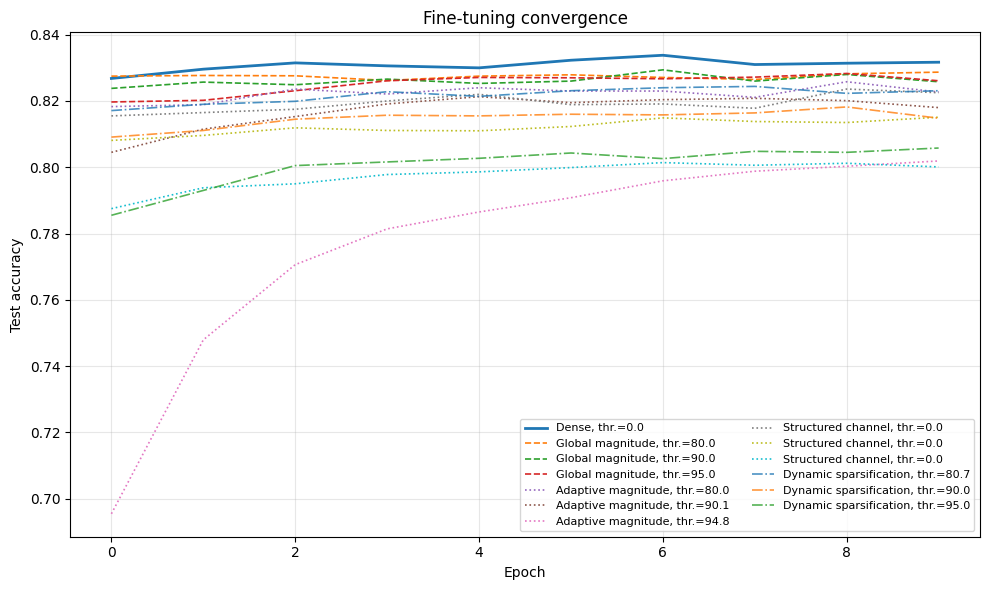

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
for result in results:
    match result['group']:
        case 'Dense':
            ls, lw, alpha = 'solid', 2, 1.0
        case 'Global magnitude':
            ls, lw, alpha = 'dashed', 1.2, 1.0
        case 'Adaptive magnitude':
            ls, lw, alpha = 'dotted', 1.2, 1.0
        case 'Structured channel':
            ls, lw, alpha = 'dotted', 1.2, 1.0
        case 'Dynamic sparsification':
            ls, lw, alpha = 'dashdot', 1.2, 0.8
    thr = (sparsity(result['model']) * 100)
    ax.plot(
        [m['Accuracy'] for m in result['history']],
        ls=ls,
        lw=lw,
        alpha=alpha,
        label=f"{result['group']}, thr.={thr:.1f}"
    )
ax.set_xlabel('Epoch')
ax.set_ylabel('Test accuracy')
ax.set_title('Fine-tuning convergence')
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()

Overall, all pruning strategies effectively highlighted the most informative neurons in the network. With some techniques, removing as much as 95% of the weights led to only a minor decrease in prediction quality, which I consider an outstanding result for a demonstration study. However, only structured channel pruning resulted in an actual performance improvement of the network, which is mostly manifested in the reduction of the memory footprint. Other techniques rely on simply masking the weights, which requires specialized hardware that supports computations with sparse matrices to achieve an observable effect on the memory and performance of the model.

Therefore, pruning is a powerful tool to explore the behavior of the neural network and isolate the most important weights without losing accuracy, which might be as few as 5% of the model. However, most pruning techniques require specialize hardware (Ampere+, RTX 30-series GPU, etc.) tuned for sparse computations to get a real effect on the performance of the neural network. On a typical consumer GPU (like a GTX 1660 Super used in the study), no real improvement is feasible. This might change with the implementation of the torch.sparse module, yet it is still experimental and is not supported even by the core torch implementations, including standard convolution layers.

As a final remark, it is worth mentioning the existing implementation of pruning in the torch.utils.prune module. Although it was not used in the study, it might be useful in production to test sparsity hypotheses easier. Yet, it is always implemented by masking the weights, and thus does not lead to performance improvements even for the structured channel strategy.